In [1]:
import os 
os.chdir("..")
print(os.getcwd())
import gc
import torch

d:\pythonProject\IC Lab\Gait_analysis\pyskl


In [3]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
n = 5
def vote_test_predictions(n = 5, mode='hard'):
    assert mode in ['hard', 'soft'], "Voting mode must be either 'hard' or 'soft'"

    if mode == 'hard':
        all_preds = [np.argmax(np.load(f'ensemble_preds/logits_fold{i}.npy'), axis=1) for i in range(n)]
        all_preds = np.stack(all_preds, axis=0)  # shape: (n_models, num_samples)

        # 加入 tie-breaking 的 lambda（處理平票時隨機選一個）
        def vote_with_tie_breaking(x):
            counts = np.bincount(x)
            max_vote = counts.max()
            candidates = np.flatnonzero(counts == max_vote)
            return np.random.choice(candidates)

        voted = np.apply_along_axis(vote_with_tie_breaking, axis=0, arr=all_preds)
    else:
        all_logits = [np.load(f'ensemble_preds/logits_fold{i}.npy') for i in range(n)]
        mean_logits = np.mean(np.stack(all_logits, axis=0), axis=0)
        voted = np.argmax(mean_logits, axis=1)

    labels = np.load('ensemble_preds/labels_fold0.npy')

    # reset_metrics()
    # update_metrics(preds=voted, labels=labels)
    # metrics = compute_metrics()

    acc = accuracy_score(labels, voted)
    f1 = f1_score(labels, voted, average='macro')

    print(f"\n✅ {mode.capitalize()} Voting Result: Acc={acc:.4f}, F1={f1:.4f}")
    
    # return {'test_metrics': {
    #     "loss": 0,
    #     "acc_4c": metrics["acc_4c"],
    #     "acc_3c": metrics["acc_3c"],
    #     "acc_2c": metrics["acc_2c"],
    #     "precision_2c": metrics["precision_2c"],
    #     "recall_2c": metrics["recall_2c"],
    #     "f1_2c": metrics["f1_2c"]
    # }}, args

vote_test_predictions(n=5, mode='hard')


✅ Hard Voting Result: Acc=0.7778, F1=0.6625


In [2]:
from colab.SSO import SSO
from colab.tools import prinfo

In [3]:
run = 5
l = [
    r"C:\Users\User\Downloads\drunk_8_789_run4_ggen6_gsol3_searchtime38798.10474252701_12026331.pkl",
]

for i in l:
    SSO_reader = SSO()
    SSO_reader.load_result(i)
    best_split8_log = SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message']['log']
    best_split8_log = os.path.basename(best_split8_log)
    command = f"python -m colab.training_tools.inference_split9 --txt {best_split8_log}"

    try:
        # 執行並收集輸出
        b = !{command}
        # print(b)

        # 使用 `prinfo()` 解析結果
        (
            train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c,
            test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log
        ) = prinfo(b)

        print(f"Run : {run-1:>3} | Train_cost : {train_cost:>8.3f}s | Train_time : {train_time:>8.7f}s | "
              f"Test_time : {test_time:>8.3f}s | Val_acc_4c : {val_acc_4c:>10.7f} | "
              f"Val_acc_3c : {val_acc_3c:>10.7f} | Val_acc_2c : {val_acc_2c:>10.7f} | "
              f"Test_acc_4c : {test_acc_4c:>10.7f} | Test_acc_3c : {test_acc_3c:>10.7f} | "
              f"Test_acc_2c : {test_acc_2c:>10.7f} | F1 : {f1:>10.7f} | "
              f"Precision : {pre:>10.7f} | Recall : {rec:>10.7f} | Log : {log}")

        record_message = {
            'train_cost': train_cost,
            'train_time': train_time,
            'test_time': test_time,
            'val_acc_4c': val_acc_4c,
            'val_acc_3c': val_acc_3c,
            'val_acc_2c': val_acc_2c,
            'test_acc_4c': test_acc_4c,
            'test_acc_3c': test_acc_3c,
            'test_acc_2c': test_acc_2c,
            'f1': f1,
            'precision': pre,
            'recall': rec,
            'log': log
        }

        # 重新存split 9
        import uuid
        import pickle

        split = 9
        SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message'] = record_message
        unique_id = uuid.uuid4().hex[:8]
        save_name = f"{'drunk'}_{split}_{789}_run{run-1}"
        save_path = f"sso_result/{save_name}_ggen{SSO_reader.genBest}_gsol{SSO_reader.gBest}_searchtime{SSO_reader.search_time}_{unique_id}.pkl"

        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        with open(save_path, 'wb') as f:
            pickle.dump(SSO_reader.ckpt, f)
        print(f"📄 記錄檔已儲存至：{save_path}")
        print("-" * 40)

        SSO_reader.result_summary()

    except Exception as e:
        print(f"❌ 發生錯誤: {e}")
        train_cost = train_time = test_time = 0
        val_acc_4c = val_acc_3c = val_acc_2c = 0
        test_acc_4c = test_acc_3c = test_acc_2c = 0
        f1 = pre = rec = 0
        log = ""



🔄 Loading from saved checkpoint...
📂 File ggen: 6, gsol: 3


Run :   4 | Train_cost :   15.672s | Train_time : 0.0000000s | Test_time :   14.127s | Val_acc_4c :  0.0000000 | Val_acc_3c :  0.0000000 | Val_acc_2c :  0.0000000 | Test_acc_4c :  0.7756944 | Test_acc_3c :  0.8979167 | Test_acc_2c :  0.9812500 | F1 :  0.9809457 | Precision :  0.9971306 | Recall :  0.9652778 | Log : results/record_20250420_112714_drunk_j_split9_4C-0.7757_3C-0.8979_2C-0.9812_2CP-0.9971_2CR-0.9653_2CF-0.9809.txt
📄 記錄檔已儲存至：sso_result/drunk_9_789_run4_ggen6_gsol3_searchtime0_0dc3758d.pkl
----------------------------------------
🚀 Search Results Summary
✅ Search 完成！
🔍 最佳解所在世代編號：6
🔍 最佳解索引編號：3
----------------------------------------
🏆 Optimal Solution Details:
  - Optimal Solution: {'x': ((102.0, 2.0, 1.0, 1.0, 0.0, 0.25352534351159817, 0.18852922665242283, 0.04636327733931111, 0.009358691047859245, 0.6224780455491729, 0.5031216731056983, 0.8607590325684799), 0.859375), 'message': {'train_cost': 15.6717, 'train_time': 0.0, 'test_time': 14.126811504364014, 'val_acc_4c': 0.0, '

In [5]:
import os
from pathlib import Path
from colab.tools import prinfo
# 1️⃣ 讀取 results/ 底下所有 .txt 檔案
results_dir = Path("results")
txt_files = sorted([f.name for f in results_dir.glob("*.txt")])

# 2️⃣ 執行每個推論命令
for run, txt_file in enumerate(txt_files):
    
    # 組成 shell command
    command = f"python -m colab.training_tools.inference_split6 --txt {txt_file}"
    
    # 執行並收集輸出
    b = !{command}
    # print(b)
    
    # 使用 `prinfo()` 解析結果
    (
        train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c, 
        test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log
    ) = prinfo(b)

    print(f"Run : {run:>3} | Train_cost : {train_cost:>8.3f}s | Train_time : {train_time:>8.7f}s | "
              f"Test_time : {test_time:>8.3f}s | Val_acc_4c : {val_acc_4c:>10.7f} | "
              f"Val_acc_3c : {val_acc_3c:>10.7f} | Val_acc_2c : {val_acc_2c:>10.7f} | "
              f"Test_acc_4c : {test_acc_4c:>10.7f} | Test_acc_3c : {test_acc_3c:>10.7f} | "
              f"Test_acc_2c : {test_acc_2c:>10.7f} | F1 : {f1:>10.7f} | "
              f"Precision : {pre:>10.7f} | Recall : {rec:>10.7f} | Log : {log}")

Run :   0 | Train_cost :    0.000s | Train_time : 0.0000000s | Test_time :    0.000s | Val_acc_4c :  0.0000000 | Val_acc_3c :  0.0000000 | Val_acc_2c :  0.0000000 | Test_acc_4c :  0.0000000 | Test_acc_3c :  0.0000000 | Test_acc_2c :  0.0000000 | F1 :  0.0000000 | Precision :  0.0000000 | Recall :  0.0000000 | Log : Unknown
Run :   1 | Train_cost :    0.000s | Train_time : 0.0000000s | Test_time :    0.000s | Val_acc_4c :  0.0000000 | Val_acc_3c :  0.0000000 | Val_acc_2c :  0.0000000 | Test_acc_4c :  0.0000000 | Test_acc_3c :  0.0000000 | Test_acc_2c :  0.0000000 | F1 :  0.0000000 | Precision :  0.0000000 | Recall :  0.0000000 | Log : Unknown
Run :   2 | Train_cost :    0.000s | Train_time : 0.0000000s | Test_time :    0.000s | Val_acc_4c :  0.0000000 | Val_acc_3c :  0.0000000 | Val_acc_2c :  0.0000000 | Test_acc_4c :  0.0000000 | Test_acc_3c :  0.0000000 | Test_acc_2c :  0.0000000 | F1 :  0.0000000 | Precision :  0.0000000 | Recall :  0.0000000 | Log : Unknown
Run :   3 | Train_cost : 

In [6]:
from colab.tools import fix_ckpt_to_result
fix_ckpt_to_result(log_path="sso_checkpoint/log.pkl" ,data='drunk', split=25, setting=777)

ckpt is transed to result pkl.


True

In [7]:
from colab.SSO import SSO

split = 1
sso_setting = 789

# SSO超參數
SSO_config = {789: {'Cg':0.7, 'Cp':0.8, 'Cw':0.9},
              189: {'Cg':0.1, 'Cp':0.8, 'Cw':0.9},
              129: {'Cg':0.1, 'Cp':0.2, 'Cw':0.9},
              123: {'Cg':0.1, 'Cp':0.2, 'Cw':0.3}}

# MT 最好的參數
MT = {  1 : {'margin': 0.6, 'lambda':0.75},
        2 : {'margin': 0.2, 'lambda': 0.75},
        3 : {'margin': 0.2, 'lambda': 0.75},
        4 : {'margin': 0.6, 'lambda': 0.75},
        5 : {'margin': 0.6, 'lambda': 0.75}
    }

params_range = {
'base_channel'  : (32, 128),
'num_init'      : (1, 4),

'num_in'        : (0, 3),           # num_layers_input_stream
'tkernel_in'    : [3, 5, 7],        # tkernel_input_stream
'stride_in'     : (1, 3),           # stride_input_stream
'oc_in'         : (64, 256),        # output_channel_input_stream

'num_main'      : (0, 3),           # num_layers_main_stream
'tkernel_main'  : [3, 5, 7],        # tkernel_main_stream
'stride_main'   : (1, 3),           # stride_main_stream
'oc_main'       : (64, 256),        # output_channel_main_stream

'act'           : (0, 3),           # activate function  
'opt'           : (0, 2),           # optimizer

'dropout_bk'    : (0.15, 0.3),      # dropout in block
'dropout_fc'    : (0.15, 0.3),      # dropout in fc

'lr'            : (0.001, 0.1),     # learning rate
'weight_decay'  : (0.0, 0.01),        # weight_decay
'momentum'      : (0.5, 0.99),      # momentum
'margin'        : (0.25, 1),        # margin in Triplet Loss
'lambda_val'    : (0.0, 0.9),           # The ratio of Triplet Loss compare to Cross Entropy
}

# 設定初始解
params = {
    'data'          : 'drunk',          # 我自己讀特定資料集的方式
    'batch'         : 128,              # 可以調整~~
    'epoch'         : 80,               # 可以調整~~
    'feature'       : 'j',              # 我自己讀特定資料集的方式
    'split'         : split,

    'base_channel'  : 64,               # output_channel in init_layer
    'num_init'      : 4,

    'num_in'        : 3,                # num_layers_input_stream
    'tkernel_in'    : 3,                # tkernel_input_stream
    'stride_in'     : 2,                # stride_input_stream
    'oc_in'         : 128,              # output_channel_input_stream

    'num_main'      : 3,                # num_layers_main_stream
    'tkernel_main'  : 3,                # tkernel_main_stream
    'stride_main'   : 2,                # stride_main_stream
    'oc_main'       : 256,              # output_channel_main_stream

    'act'           : 0,                # activate function
    'opt'           : 0,                # optimizer
    
    'dropout_bk'    : 0,                # dropout in block
    'dropout_fc'    : 0,                # dropout in fc

    'lr'            : 0.1,              # learning rate
    'weight_decay'  : 0.0005,           # weight_decay
    'momentum'      : 0.9,              # momentum
    'margin'        : MT[split]['margin'],              # margin in Triplet Loss
    'lambda_val'    : MT[split]['lambda'],              # The ratio of Triplet Loss compare to Cross Entropy
}
                                                                                                        
# 不用動
def get_param(X, keys=params_range.keys(), params=params):
    """
    Update `param` dictionary based on `keys` and corresponding values from `X`.

    Parameters:
        X (numpy.ndarray): Array of parameter values corresponding to the keys.
        keys (list): List of parameter names (keys) used to map values in X.
        params_range (dict): Search range for each parameter, where values can be
                            tuples (for range) or lists (for discrete options).

    Returns:
        dict: Updated `param` dictionary with values from `X`, converting to int if needed.
    """
    # 創建 `param` 的拷貝，避免修改原始字典
    param = params.copy()

    # 根據 keys 中的索引更新 param 中對應的鍵
    for i, key in enumerate(keys):
        # 判斷該參數是否需要轉換為整數
        boundary = params_range[key]
        if (
            isinstance(boundary, tuple) and all(isinstance(b, int) for b in boundary)
        ) or (
            isinstance(boundary, list) and all(isinstance(b, int) for b in boundary)
        ):
            # 如果是整數範圍或整數列表，將值轉換為整數
            param[key] = int(X[i])
        else:
            # 否則保留原類型
            param[key] = X[i]

    return param

def fitness(X):
    # **釋放 GPU 記憶體**
    torch.cuda.empty_cache()
    
    param = get_param(X=X)
    param_args = " ".join([f"--{key} {str(value).strip()}" for key, value in param.items()])
    command = f"python -m colab.training_tools.kaggle_train_drunk_aug_multimetric_weight_small_lambda_gpu --mt --timeout 800 {param_args}"
    
    try:
        # 使用 `!{command}` 在 Jupyter Notebook / Colab 內執行
        output = !{command}
        # print(output)
        # 解析輸出
        train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c, \
        test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log = prinfo(output)

    except Exception as e:
        print(f"❌ 發生錯誤: {e}")
        # 確保所有變數有值，避免 `NoneType` 出錯
        train_cost = train_time = test_time = 0
        val_acc_4c = val_acc_3c = val_acc_2c = 0
        test_acc_4c = test_acc_3c = test_acc_2c = 0
        f1 = pre = rec = 0
        log = ""

    # 確保 `NoneType` 不影響計算
    fitness_value = (val_acc_4c or 0) + (val_acc_3c or 0) + (val_acc_2c or 0)

    # 確保 `log` 不為 `None`
    log = log if log is not None else ""

    record_message = {
        'train_cost': train_cost,
        'train_time': train_time,
        'test_time': test_time,
        'val_acc_4c': val_acc_4c,
        'val_acc_3c': val_acc_3c,
        'val_acc_2c': val_acc_2c,
        'test_acc_4c': test_acc_4c,
        'test_acc_3c': test_acc_3c,
        'test_acc_2c': test_acc_2c,
        'f1': f1,
        'precision': pre,
        'recall': rec,
        'log': log
    }
    
    return fitness_value, record_message

save_name = f"{params['data']}_{params['split']}_{sso_setting}"

SSO_searcher = SSO(
    Ngen=15,                                # 世代數
    Nsol=10,                                # 解的數量
    Cg=SSO_config[sso_setting]['Cg'],                                 # 全局最佳解的權重
    Cp=SSO_config[sso_setting]['Cp'],                                 # 個體最佳解的權重
    Cw=SSO_config[sso_setting]['Cw'],                                 # 隨機解的權重
    save_name=save_name,                    # 記錄檔儲存前綴
    fitness=fitness,                        # 適應度函數
    base_param=params,                      # 基礎參數 (可選)
    boundary=params_range,                  # 支持 tuple 或 list (詳細說明請參照前述)
    direction="maximize",                   # 優化方向 ('maximize', 'minimize')
    )

# 直接運行
SSO_searcher.resume_run(log_file=r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_checkpoint\log.pkl")

# SSO_searcher.plot()
# **手動刪除變數**
del SSO_searcher
# **強制執行垃圾回收**
gc.collect()



FileNotFoundError: [Errno 2] No such file or directory: 'D:\\pythonProject\\IC Lab\\Gait_analysis\\pyskl\\sso_checkpoint\\log.pkl'

In [ ]:
import numpy as np

data = np.load(r'D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\dist\drunk_split4.npz', allow_pickle=True)
logits = data['logits']

print("Logits NaN:", np.isnan(logits).sum())
print("Logits Inf:", np.isinf(logits).sum())
print("Total samples:", logits.shape[0])

Logits NaN: 0
Logits Inf: 0
Total samples: 3968


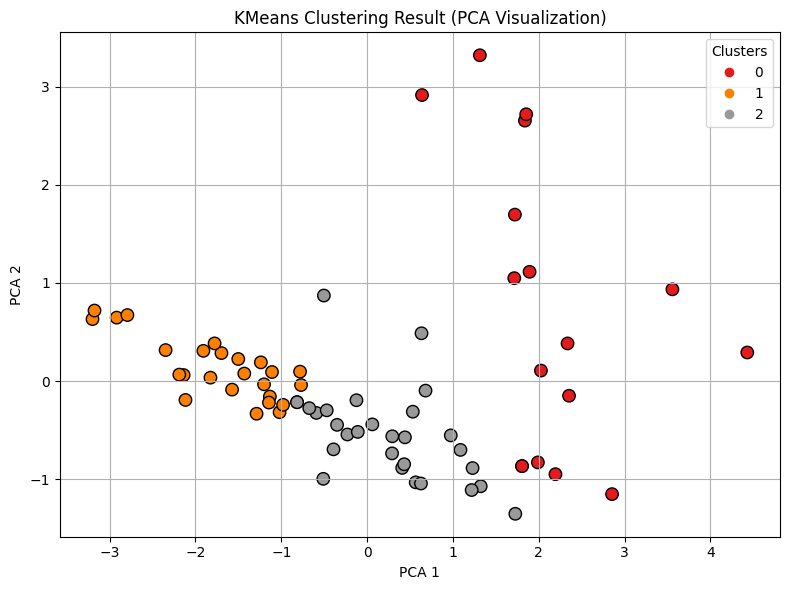

已儲存至：分群結果_酒精步態資料_K2.xlsx


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# 讀取 Excel 檔案
file_path = r"C:\Users\User\Downloads\酒精步態資料集受試者資訊 (回覆) (1).xlsx"
df = pd.read_excel(file_path)

# 選擇要用來分群的欄位並移除缺失值
features = df[['年齡(歲)', '身高(cm)', '體重(kg)', 'BMI']].dropna()

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# KMeans 分為 2 群
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 記錄分群結果
df_cleaned = df.loc[features.index].copy()
df_cleaned['Cluster'] = clusters

# 選擇性標記每個類別為 True/False（例如 Cluster 0）
df_cleaned['Cluster_0'] = df_cleaned['Cluster'] == 0
df_cleaned['Cluster_1'] = df_cleaned['Cluster'] == 1

from sklearn.decomposition import PCA

# PCA 降到 2 維
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 繪圖：顯示 KMeans 分群後的結果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', edgecolors='k', s=80)
plt.title('KMeans Clustering Result (PCA Visualization)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="best")
plt.tight_layout()
plt.show()

# 儲存為新檔案
save_path = "分群結果_酒精步態資料_K2.xlsx"
df_cleaned.to_excel(save_path, index=False)
print(f"已儲存至：{save_path}")


✅ 已儲存分群結果到：分群結果_酒精步態資料_K2.xlsx

各群體資料範圍（最小值與最大值）：
         年齡(歲)_min  身高(cm)_min  體重(kg)_min    BMI_min  性別_min  年齡(歲)_max  \
Cluster                                                                    
-1              33       170.0          56  16.470588       1         33   
 0              20       157.0          54  16.167665       0         51   
 1              21       151.0          41  13.398693       1         24   
 2              47       165.0          63  19.090909       1         48   

         身高(cm)_max  體重(kg)_max    BMI_max  性別_max  
Cluster                                             
-1            170.0          56  16.470588       1  
 0            188.0          98  26.878613       0  
 1            173.0          66  20.121951       1  
 2            165.0          75  22.727273       1  


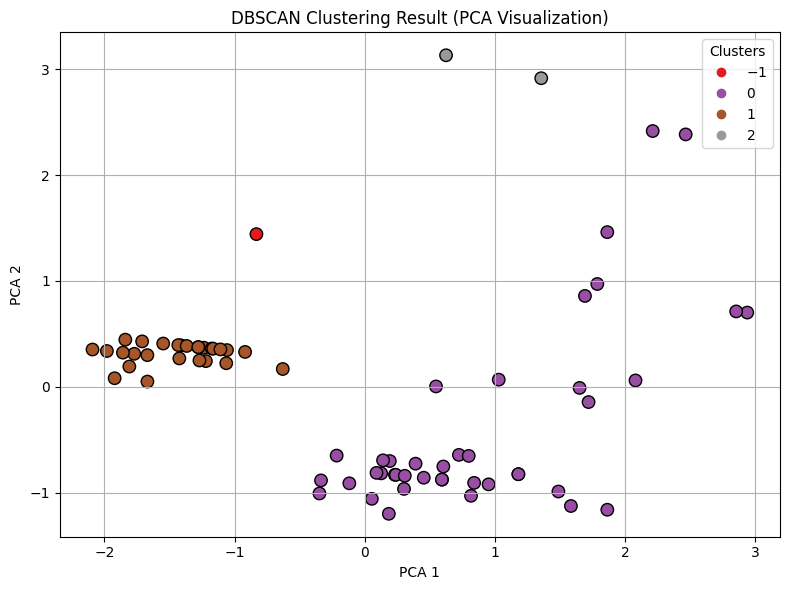

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# 讀取 Excel 檔案
file_path = r"C:\Users\User\Downloads\酒精步態資料集受試者資訊 (回覆) (1).xlsx"
df = pd.read_excel(file_path)
df['性別'] = df['性別'].map({'男': 0, '女': 1})
# 選擇特徵欄位並去除缺失值
features = df[['年齡(歲)', 'BMI', '性別']].dropna()

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 使用 DBSCAN 進行分群
dbscan = DBSCAN(eps=1.2, min_samples=2)
clusters = dbscan.fit_predict(X_scaled)

# 將分群結果加入原資料
df_cleaned = df.loc[features.index].copy()
df_cleaned['Cluster'] = clusters

# 可選：也標記 Cluster_0, Cluster_1（非必要）
df_cleaned['Cluster_0'] = df_cleaned['Cluster'] == 0
df_cleaned['Cluster_1'] = df_cleaned['Cluster'] == 1

# 將結果存檔
# save_path = r"C:\Users\User\Downloads\分群結果_酒精步態資料_DBSCAN.xlsx"
df_cleaned.to_excel(save_path, index=False)
print(f"✅ 已儲存分群結果到：{save_path}")

# 使用 PCA 將特徵降維至 2D 以視覺化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 查看各群體的平均年齡、身高、體重、BMI
group_range_min = df_cleaned.groupby("Cluster")[['年齡(歲)', '身高(cm)', '體重(kg)', 'BMI', '性別']].min().add_suffix('_min')
group_range_max = df_cleaned.groupby("Cluster")[['年齡(歲)', '身高(cm)', '體重(kg)', 'BMI', '性別']].max().add_suffix('_max')

# 合併 min 和 max
group_range = pd.concat([group_range_min, group_range_max], axis=1)

# 顯示結果
print("\n各群體資料範圍（最小值與最大值）：")
print(group_range)

# 繪圖顯示分群結果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', edgecolors='k', s=80)
plt.title('DBSCAN Clustering Result (PCA Visualization)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="best")
plt.tight_layout()
plt.show()

# 測試KMEANS 劃分

In [ ]:
from colab.tools import prinfo

In [ ]:
for split in range(6, 9):
    print(f" SPLIT : {split}")
    command = f"python -m colab.training_tools.kaggle_train_drunk_aug_multimetric_weight_small_lambda_gpu --batch 128 --data drunk --feature j --epochs 80 --split {split} --cls 4 --model stgcn --loss CE"
    for run in range(5):
        b = !{command}
        (
            train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c, 
            test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log
        ) = prinfo(b)

        # 輸出結果
        print(f"Run : {run:>3} | Train_cost : {train_cost:>8.3f}s | Train_time : {train_time:>8.7f}s | "
              f"Test_time : {test_time:>8.3f}s | Val_acc_4c : {val_acc_4c:>10.7f} | "
              f"Val_acc_3c : {val_acc_3c:>10.7f} | Val_acc_2c : {val_acc_2c:>10.7f} | "
              f"Test_acc_4c : {test_acc_4c:>10.7f} | Test_acc_3c : {test_acc_3c:>10.7f} | "
              f"Test_acc_2c : {test_acc_2c:>10.7f} | F1 : {f1:>10.7f} | "
              f"Precision : {pre:>10.7f} | Recall : {rec:>10.7f} | Log : {log}")

 SPLIT : 6
Run :   0 | Train_cost :  283.961s | Train_time : 250.0503595s | Test_time :    6.721s | Val_acc_4c :  0.5683594 | Val_acc_3c :  0.6608073 | Val_acc_2c :  0.8372396 | Test_acc_4c :  0.5674242 | Test_acc_3c :  0.6565657 | Test_acc_2c :  0.8404040 | F1 :  0.8621291 | Precision :  0.7588326 | Recall :  0.9979798 | Log : results/record_20250412_000435_drunk_j_split6_4C-0.5674_3C-0.6566_2C-0.8404_2CP-0.7588_2CR-0.9980_2CF-0.8621.txt
Run :   1 | Train_cost :  267.272s | Train_time : 233.7790315s | Test_time :    7.111s | Val_acc_4c :  0.6064453 | Val_acc_3c :  0.6458333 | Val_acc_2c :  0.9163411 | Test_acc_4c :  0.6101010 | Test_acc_3c :  0.6477273 | Test_acc_2c :  0.9179293 | F1 :  0.9237984 | Precision :  0.8621444 | Recall :  0.9949495 | Log : results/record_20250412_000911_drunk_j_split6_4C-0.6101_3C-0.6477_2C-0.9179_2CP-0.8621_2CR-0.9949_2CF-0.9238.txt
Run :   2 | Train_cost :  366.370s | Train_time : 332.3509367s | Test_time :    7.904s | Val_acc_4c :  0.6627604 | Val_acc_3c

: 

In [ ]:
from colab.tools import prinfo
for split in [7]:
    print(f" SPLIT : {split}")
    command = f"python -m colab.training_tools.kaggle_train_drunk_aug_multimetric_weight_small_lambda_gpu --batch 128 --data drunk --feature j --epochs 80 --split {split} --cls 4 --model stgcn --timeout 3000 --loss CE"
    for run in range(5):
        b = !{command}
        (
            train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c, 
            test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log
        ) = prinfo(b)

        # 輸出結果
        print(f"Run : {run:>3} | Train_cost : {train_cost:>8.3f}s | Train_time : {train_time:>8.7f}s | "
              f"Test_time : {test_time:>8.3f}s | Val_acc_4c : {val_acc_4c:>10.7f} | "
              f"Val_acc_3c : {val_acc_3c:>10.7f} | Val_acc_2c : {val_acc_2c:>10.7f} | "
              f"Test_acc_4c : {test_acc_4c:>10.7f} | Test_acc_3c : {test_acc_3c:>10.7f} | "
              f"Test_acc_2c : {test_acc_2c:>10.7f} | F1 : {f1:>10.7f} | "
              f"Precision : {pre:>10.7f} | Recall : {rec:>10.7f} | Log : {log}")

 SPLIT : 7
Run :   0 | Train_cost : 1027.259s | Train_time : 990.3306825s | Test_time :    7.971s | Val_acc_4c :  0.9592634 | Val_acc_3c :  0.9829799 | Val_acc_2c :  0.9958147 | Test_acc_4c :  0.9078947 | Test_acc_3c :  0.9436404 | Test_acc_2c :  0.9859649 | F1 :  0.9861592 | Precision :  0.9726962 | Recall :  1.0000000 | Log : results/record_20250412_101252_drunk_j_split7_4C-0.9079_3C-0.9436_2C-0.9860_2CP-0.9727_2CR-1.0000_2CF-0.9862.txt
Run :   1 | Train_cost :  568.755s | Train_time : 533.3402784s | Test_time :    8.393s | Val_acc_4c :  0.8953683 | Val_acc_3c :  0.9617746 | Val_acc_2c :  0.9986049 | Test_acc_4c :  0.8574561 | Test_acc_3c :  0.9320175 | Test_acc_2c :  0.9912281 | F1 :  0.9913043 | Precision :  0.9827586 | Recall :  1.0000000 | Log : results/record_20250412_102231_drunk_j_split7_4C-0.8575_3C-0.9320_2C-0.9912_2CP-0.9828_2CR-1.0000_2CF-0.9913.txt
Run :   2 | Train_cost :  940.322s | Train_time : 905.4747758s | Test_time :    7.893s | Val_acc_4c :  0.9564732 | Val_acc_3c

In [ ]:
from colab.tools import prinfo
for split in [6, 8]:
    print(f" SPLIT : {split}")
    command = f"python -m colab.training_tools.kaggle_train_drunk_aug_multimetric_weight_small_lambda_gpu --batch 128 --data drunk --feature j --epochs 80 --split {split} --cls 4 --model stgcn --timeout 3000 --loss CE"
    for run in range(5):
        b = !{command}
        (
            train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c, 
            test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log
        ) = prinfo(b)

        # 輸出結果
        print(f"Run : {run:>3} | Train_cost : {train_cost:>8.3f}s | Train_time : {train_time:>8.7f}s | "
              f"Test_time : {test_time:>8.3f}s | Val_acc_4c : {val_acc_4c:>10.7f} | "
              f"Val_acc_3c : {val_acc_3c:>10.7f} | Val_acc_2c : {val_acc_2c:>10.7f} | "
              f"Test_acc_4c : {test_acc_4c:>10.7f} | Test_acc_3c : {test_acc_3c:>10.7f} | "
              f"Test_acc_2c : {test_acc_2c:>10.7f} | F1 : {f1:>10.7f} | "
              f"Precision : {pre:>10.7f} | Recall : {rec:>10.7f} | Log : {log}")

 SPLIT : 6
Run :   0 | Train_cost :  252.265s | Train_time : 221.0209508s | Test_time :    6.042s | Val_acc_4c :  0.6744792 | Val_acc_3c :  0.7789714 | Val_acc_2c :  0.8951823 | Test_acc_4c :  0.6651515 | Test_acc_3c :  0.7694444 | Test_acc_2c :  0.8962121 | F1 :  0.9057123 | Precision :  0.8297604 | Recall :  0.9969697 | Log : results/record_20250412_111542_drunk_j_split6_4C-0.6652_3C-0.7694_2C-0.8962_2CP-0.8298_2CR-0.9970_2CF-0.9057.txt
Run :   1 | Train_cost :  308.330s | Train_time : 274.3311388s | Test_time :    7.007s | Val_acc_4c :  0.6188151 | Val_acc_3c :  0.6754557 | Val_acc_2c :  0.8902995 | Test_acc_4c :  0.6154040 | Test_acc_3c :  0.6694444 | Test_acc_2c :  0.8888889 | F1 :  0.8997265 | Precision :  0.8197674 | Recall :  0.9969697 | Log : results/record_20250412_112059_drunk_j_split6_4C-0.6154_3C-0.6694_2C-0.8889_2CP-0.8198_2CR-0.9970_2CF-0.8997.txt
Run :   2 | Train_cost :  507.562s | Train_time : 474.3627801s | Test_time :    7.219s | Val_acc_4c :  0.5413411 | Val_acc_3c

In [ ]:
from colab.tools import prinfo
for split in [8]:
    print(f" SPLIT : {split}")
    command = f"python -m colab.training_tools.kaggle_train_drunk_aug_multimetric_weight_small_lambda_gpu --batch 128 --data drunk --feature j --epochs 80 --split {split} --cls 4 --model stgcn --timeout 3000 --loss CE"
    for run in range(5):
        b = !{command}
        (
            train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c, 
            test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log
        ) = prinfo(b)

        # 輸出結果
        print(f"Run : {run:>3} | Train_cost : {train_cost:>8.3f}s | Train_time : {train_time:>8.7f}s | "
              f"Test_time : {test_time:>8.3f}s | Val_acc_4c : {val_acc_4c:>10.7f} | "
              f"Val_acc_3c : {val_acc_3c:>10.7f} | Val_acc_2c : {val_acc_2c:>10.7f} | "
              f"Test_acc_4c : {test_acc_4c:>10.7f} | Test_acc_3c : {test_acc_3c:>10.7f} | "
              f"Test_acc_2c : {test_acc_2c:>10.7f} | F1 : {f1:>10.7f} | "
              f"Precision : {pre:>10.7f} | Recall : {rec:>10.7f} | Log : {log}")

 SPLIT : 8
Run :   0 | Train_cost :  458.191s | Train_time : 423.5369225s | Test_time :    7.356s | Val_acc_4c :  0.8057065 | Val_acc_3c :  0.8875679 | Val_acc_2c :  0.9480299 | Test_acc_4c :  0.7767677 | Test_acc_3c :  0.8722222 | Test_acc_2c :  0.9351010 | F1 :  0.9384726 | Precision :  0.8921256 | Recall :  0.9898990 | Log : results/record_20250412_121357_drunk_j_split8_4C-0.7768_3C-0.8722_2C-0.9351_2CP-0.8921_2CR-0.9899_2CF-0.9385.txt
Run :   1 | Train_cost :  264.959s | Train_time : 228.5369604s | Test_time :    7.153s | Val_acc_4c :  0.7051630 | Val_acc_3c :  0.7826087 | Val_acc_2c :  0.9551630 | Test_acc_4c :  0.6974747 | Test_acc_3c :  0.7704545 | Test_acc_2c :  0.9366162 | F1 :  0.9338952 | Precision :  0.9757843 | Recall :  0.8954545 | Log : results/record_20250412_121832_drunk_j_split8_4C-0.6975_3C-0.7705_2C-0.9366_2CP-0.9758_2CR-0.8955_2CF-0.9339.txt
Run :   2 | Train_cost :  414.135s | Train_time : 379.2117155s | Test_time :    7.326s | Val_acc_4c :  0.7404891 | Val_acc_3c

In [ ]:
from colab.tools import prinfo
for split in [8]:
    print(f" SPLIT : {split}")
    command = f"python -m colab.training_tools.kaggle_train_drunk_aug_multimetric_weight_small_lambda_gpu --batch 128 --data drunk --feature j --epochs 80 --split {split} --cls 4 --model stgcn --timeout 3000 --loss CE"
    for run in range(5):
        b = !{command}
        (
            train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c, 
            test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log
        ) = prinfo(b)

        # 輸出結果
        print(f"Run : {run:>3} | Train_cost : {train_cost:>8.3f}s | Train_time : {train_time:>8.7f}s | "
              f"Test_time : {test_time:>8.3f}s | Val_acc_4c : {val_acc_4c:>10.7f} | "
              f"Val_acc_3c : {val_acc_3c:>10.7f} | Val_acc_2c : {val_acc_2c:>10.7f} | "
              f"Test_acc_4c : {test_acc_4c:>10.7f} | Test_acc_3c : {test_acc_3c:>10.7f} | "
              f"Test_acc_2c : {test_acc_2c:>10.7f} | F1 : {f1:>10.7f} | "
              f"Precision : {pre:>10.7f} | Recall : {rec:>10.7f} | Log : {log}")

 SPLIT : 8
Run :   0 | Train_cost :  542.653s | Train_time : 510.4166005s | Test_time :    6.787s | Val_acc_4c :  0.8824728 | Val_acc_3c :  0.9395380 | Val_acc_2c :  0.9738451 | Test_acc_4c :  0.8419192 | Test_acc_3c :  0.9143939 | Test_acc_2c :  0.9601010 | F1 :  0.9608135 | Precision :  0.9439571 | Recall :  0.9782828 | Log : results/record_20250412_130911_drunk_j_split8_4C-0.8419_3C-0.9144_2C-0.9601_2CP-0.9440_2CR-0.9783_2CF-0.9608.txt
Run :   1 | Train_cost :  670.485s | Train_time : 636.3152757s | Test_time :    7.270s | Val_acc_4c :  0.8970788 | Val_acc_3c :  0.9313859 | Val_acc_2c :  0.9711277 | Test_acc_4c :  0.8391414 | Test_acc_3c :  0.8964646 | Test_acc_2c :  0.9474747 | F1 :  0.9494409 | Precision :  0.9151828 | Recall :  0.9863636 | Log : results/record_20250412_132031_drunk_j_split8_4C-0.8391_3C-0.8965_2C-0.9475_2CP-0.9152_2CR-0.9864_2CF-0.9494.txt
Run :   2 | Train_cost :  506.605s | Train_time : 471.4740422s | Test_time :    7.361s | Val_acc_4c :  0.8308424 | Val_acc_3c

In [ ]:
from colab.tools import prinfo
for split in [6]:
    print(f" SPLIT : {split}")
    command = f"python -m colab.training_tools.kaggle_train_drunk_aug_multimetric_weight_small_lambda_gpu --lr 0.01 --batch 128 --data drunk --feature j --epochs 80 --split {split} --cls 4 --model stgcn --timeout 3000 --loss CE --timeout 3000"
    for run in range(30):
        b = !{command}
        (
            train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c, 
            test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log
        ) = prinfo(b)

        # 輸出結果
        print(f"Run : {run:>3} | Train_cost : {train_cost:>8.3f}s | Train_time : {train_time:>8.7f}s | "
              f"Test_time : {test_time:>8.3f}s | Val_acc_4c : {val_acc_4c:>10.7f} | "
              f"Val_acc_3c : {val_acc_3c:>10.7f} | Val_acc_2c : {val_acc_2c:>10.7f} | "
              f"Test_acc_4c : {test_acc_4c:>10.7f} | Test_acc_3c : {test_acc_3c:>10.7f} | "
              f"Test_acc_2c : {test_acc_2c:>10.7f} | F1 : {f1:>10.7f} | "
              f"Precision : {pre:>10.7f} | Recall : {rec:>10.7f} | Log : {log}")

 SPLIT : 6
Run :   0 | Train_cost :  224.238s | Train_time : 192.6529038s | Test_time :    6.069s | Val_acc_4c :  0.6263587 | Val_acc_3c :  0.7211277 | Val_acc_2c :  0.9065897 | Test_acc_4c :  0.5898990 | Test_acc_3c :  0.6828283 | Test_acc_2c :  0.8765152 | F1 :  0.8886358 | Precision :  0.8092078 | Recall :  0.9853535 | Log : results/record_20250412_214320_drunk_j_split6_4C-0.5899_3C-0.6828_2C-0.8765_2CP-0.8092_2CR-0.9854_2CF-0.8886.txt
Run :   1 | Train_cost :  274.316s | Train_time : 239.9769065s | Test_time :    6.860s | Val_acc_4c :  0.5879755 | Val_acc_3c :  0.6514946 | Val_acc_2c :  0.8716033 | Test_acc_4c :  0.5484848 | Test_acc_3c :  0.6156566 | Test_acc_2c :  0.8419192 | F1 :  0.8621753 | Precision :  0.7642467 | Recall :  0.9888889 | Log : results/record_20250412_214804_drunk_j_split6_4C-0.5485_3C-0.6157_2C-0.8419_2CP-0.7642_2CR-0.9889_2CF-0.8622.txt
Run :   2 | Train_cost :  290.327s | Train_time : 257.2171741s | Test_time :    7.422s | Val_acc_4c :  0.6226223 | Val_acc_3c

In [ ]:
from colab.tools import prinfo
for split in [6]:
    print(f" SPLIT : {split}")
    command = f"python -m colab.training_tools.kaggle_train_drunk_aug_multimetric_weight_small_lambda_gpu --lr 0.01 --batch 128 --data drunk --feature j --epochs 80 --split {split} --cls 4 --model stgcn --timeout 3000 --loss CE --timeout 3000"
    for run in range(30):
        b = !{command}
        (
            train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c, 
            test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log
        ) = prinfo(b)

        # 輸出結果
        print(f"Run : {run:>3} | Train_cost : {train_cost:>8.3f}s | Train_time : {train_time:>8.7f}s | "
              f"Test_time : {test_time:>8.3f}s | Val_acc_4c : {val_acc_4c:>10.7f} | "
              f"Val_acc_3c : {val_acc_3c:>10.7f} | Val_acc_2c : {val_acc_2c:>10.7f} | "
              f"Test_acc_4c : {test_acc_4c:>10.7f} | Test_acc_3c : {test_acc_3c:>10.7f} | "
              f"Test_acc_2c : {test_acc_2c:>10.7f} | F1 : {f1:>10.7f} | "
              f"Precision : {pre:>10.7f} | Recall : {rec:>10.7f} | Log : {log}")

C:\Users\User\AppData\Local\Temp\ipykernel_35824\3817531021.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 1].legend(prop=my_font)  # ✅ 圖例中文字型補上
C:\Users\User\AppData\Local\Temp\ipykernel_35824\3817531021.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='性別', y='身高(cm)', ax=axs[1, 0], palette={'男': '#1f77b4', '女': '#ff7f0e'})
C:\Users\User\AppData\Local\Temp\ipykernel_35824\3817531021.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='性別', y='體重(kg)', ax=axs[1, 1], palette={'男': '#1f77b4', '女': '#ff7f0e'})


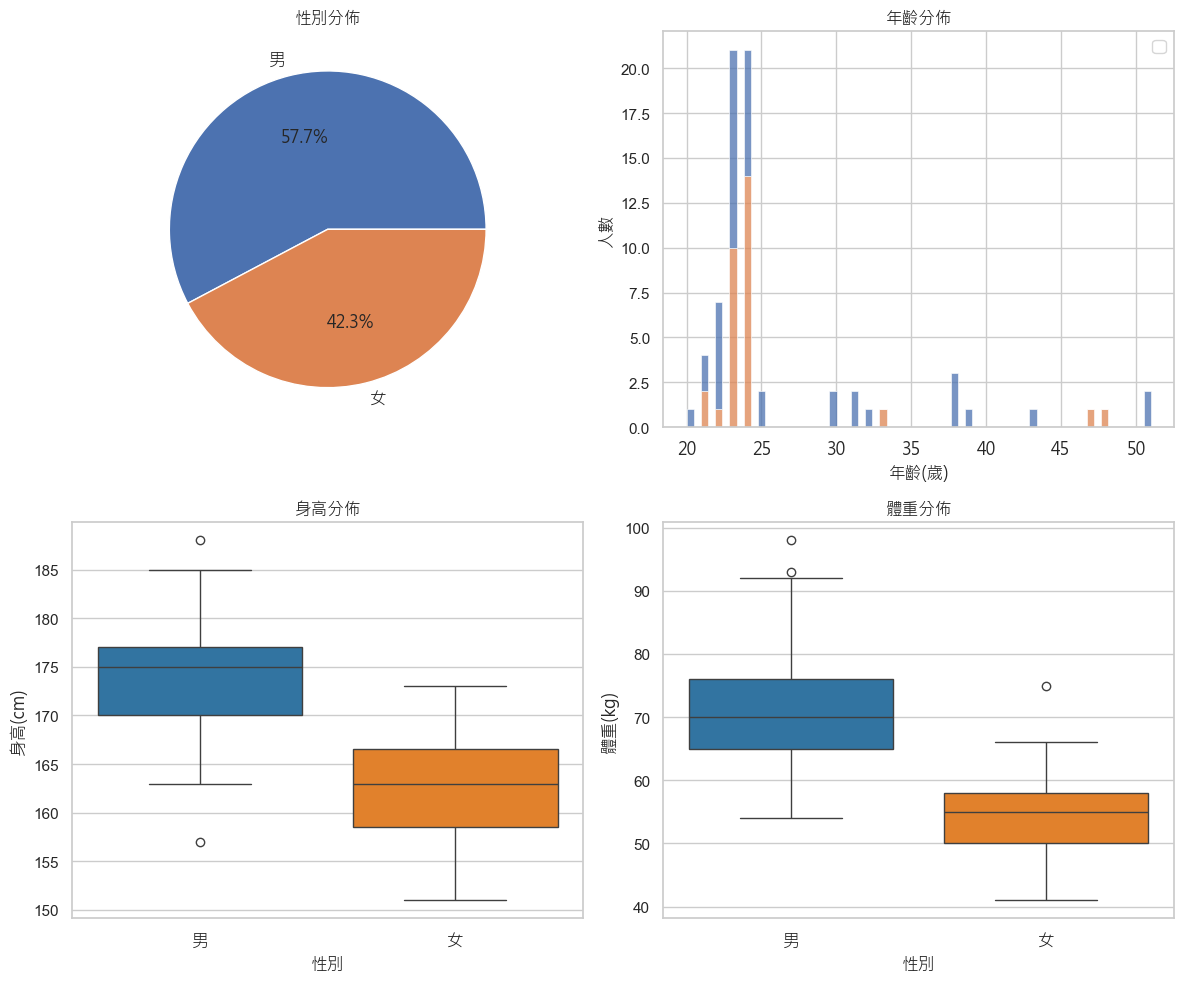

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib

# 1. 讀取 Excel 資料
file_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\info.xlsx"  # ← 修改成實際路徑
df = pd.read_excel(file_path)

# 2. 預處理欄位型態
df['性別'] = df['性別'].astype(str)
df['年齡(歲)'] = pd.to_numeric(df['年齡(歲)'], errors='coerce')
df['身高(cm)'] = pd.to_numeric(df['身高(cm)'], errors='coerce')
df['體重(kg)'] = pd.to_numeric(df['體重(kg)'], errors='coerce')

# 1. 強制中文字型設定
matplotlib.rcParams['axes.unicode_minus'] = False
font_path = r"C:\Windows\Fonts\msjh.ttc"  # 微軟正黑體
my_font = fm.FontProperties(fname=font_path)

# 4. 統計摘要
summary = {
    '性別人數 (男/女)': f"{len(df)} ({(df['性別'] == '男').sum()}:{(df['性別'] == '女').sum()})",
    '性別比例 (男/女)': f"{(df['性別'] == '男').sum() / (df['性別'] == '女').sum():.2f}:1",
    '體重': f"{df['體重(kg)'].mean():.2f} ± {df['體重(kg)'].std():.2f} kg",
    '身高': f"{df['身高(cm)'].mean():.2f} ± {df['身高(cm)'].std():.2f} cm",
    '年齡': f"{df['年齡(歲)'].mean():.2f} ± {df['年齡(歲)'].std():.3f} years"
}

# 5. 畫圖
sns.set(style="whitegrid")
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# (1) 性別圓餅圖
gender_counts = df['性別'].value_counts()
axs[0, 0].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    textprops={'fontproperties': my_font}
)
axs[0, 0].set_title('性別分佈', fontproperties=my_font)

# (2) 年齡直方圖
sns.histplot(data=df, x='年齡(歲)', hue='性別', multiple='stack', ax=axs[0, 1])
axs[0, 1].set_title('年齡分佈', fontproperties=my_font)
axs[0, 1].set_xlabel('年齡(歲)', fontproperties=my_font)
axs[0, 1].set_ylabel('人數', fontproperties=my_font)
axs[0, 1].legend(prop=my_font)  # ✅ 圖例中文字型補上
for label in axs[0, 1].get_xticklabels():
    label.set_fontproperties(my_font)

# (3) 身高 Boxplot
sns.boxplot(data=df, x='性別', y='身高(cm)', ax=axs[1, 0], palette={'男': '#1f77b4', '女': '#ff7f0e'})
axs[1, 0].set_title('身高分佈', fontproperties=my_font)
axs[1, 0].set_xlabel('性別', fontproperties=my_font)
axs[1, 0].set_ylabel('身高(cm)', fontproperties=my_font)
for label in axs[1, 0].get_xticklabels():
    label.set_fontproperties(my_font)

# (4) 體重 Boxplot
sns.boxplot(data=df, x='性別', y='體重(kg)', ax=axs[1, 1], palette={'男': '#1f77b4', '女': '#ff7f0e'})
axs[1, 1].set_title('體重分佈', fontproperties=my_font)
axs[1, 1].set_xlabel('性別', fontproperties=my_font)
axs[1, 1].set_ylabel('體重(kg)', fontproperties=my_font)
for label in axs[1, 1].get_xticklabels():
    label.set_fontproperties(my_font)
    
plt.tight_layout()
plt.show()

# # 6. 輸出統計摘要
# for k, v in summary.items():
#     print(f"{k}\t{v}")

In [5]:
from matplotlib.font_manager import fontManager
>>> for i in sorted(fontManager.get_font_names()):
...     print(i)

AIGDT
AMGDT
AcadEref
Agency FB
Algerian
AmdtSymbols
Arial
Arial Rounded MT Bold
Arial Unicode MS
Artifakt Element
Bahnschrift
BankGothic Lt BT
BankGothic Md BT
Baskerville Old Face
Bauhaus 93
Bell MT
Berlin Sans FB
Berlin Sans FB Demi
Bernard MT Condensed
Blackadder ITC
Bodoni MT
Book Antiqua
Bookman Old Style
Bookshelf Symbol 7
Bradley Hand ITC
Britannic Bold
Broadway
Brush Script MT
Calibri
Californian FB
Calisto MT
Cambria
Candara
Cascadia Code
Cascadia Mono
Castellar
Centaur
Century
Century Gothic
Century Schoolbook
Chiller
CityBlueprint
Colonna MT
Comic Sans MS
CommercialPi BT
CommercialScript BT
Complex
Consolas
Constantia
Cooper Black
Copperplate Gothic Bold
Copperplate Gothic Light
Corbel
CountryBlueprint
Courier New
Curlz MT
DFKai-SB
DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif Display
Dubai
Dutch801 Rm BT
Dutch801 XBd BT
Ebrima
Edwardian Script ITC
Elephant
Engravers MT
Eras Bold ITC
Eras Demi ITC
Eras Light ITC
Eras Medium ITC
EuroRoman
FZShuTi


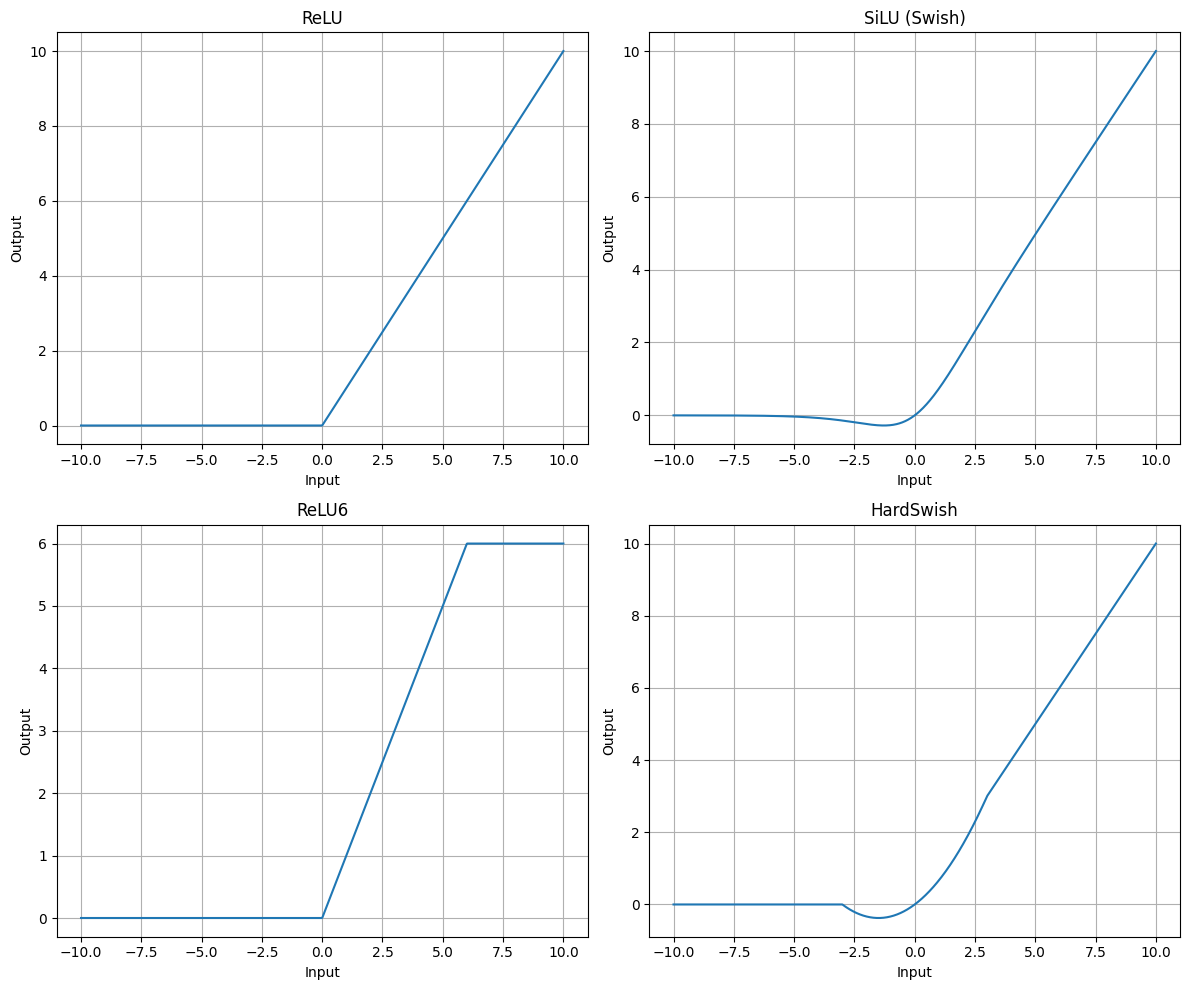

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 定義輸入範圍
x = np.linspace(-10, 10, 1000)

# 定義各種激活函數
def relu(x):
    return np.maximum(0, x)

def silu(x):  # swish(x) = x * sigmoid(x)
    return x / (1 + np.exp(-x))

def relu6(x):
    return np.minimum(np.maximum(0, x), 6)

def hardswish(x):
    return x * np.minimum(np.maximum((x + 3) / 6, 0), 1)

# 計算各函數輸出
y_relu = relu(x)
y_silu = silu(x)
y_relu6 = relu6(x)
y_hardswish = hardswish(x)

# 繪圖（4 張子圖）
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].plot(x, y_relu)
axs[0, 0].set_title('ReLU')
axs[0, 0].grid(True)

axs[0, 1].plot(x, y_silu)
axs[0, 1].set_title('SiLU (Swish)')
axs[0, 1].grid(True)

axs[1, 0].plot(x, y_relu6)
axs[1, 0].set_title('ReLU6')
axs[1, 0].grid(True)

axs[1, 1].plot(x, y_hardswish)
axs[1, 1].set_title('HardSwish')
axs[1, 1].grid(True)

for ax in axs.flat:
    ax.set(xlabel='Input', ylabel='Output')

plt.tight_layout()
plt.show()
